In [1]:
import warnings
warnings.filterwarnings('ignore')
from popsycle import synthetic
from popsycle import utils
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack
import synthpop
import pdb
import time

# SynthPop

This is where you generate the stellar model. Start by initializing SynthPop object with the configuration of your choice.
This may take a few minutes if it needs to download isochrones and/or several seconds to load a large extinction map file.

For PopSyCLE, it is required to use the popsycle_post_processing module to get your data in the right format. Additionally, you must use absolute magnitudes and use filters that PopSyCLE can interpret.

In [2]:
sp_mod = synthpop.SynthPop('huston2025_defaults.synthpop_conf', # set default figuration, then set any overrides as kwargs
                           output_location="synthpop_output",  # where to place the synthpop output
                           obsmag = False, # keep magnitudes in absolute
                           name_for_output='synthpopsycle_multiples', output_filename_pattern="{name_for_output}_l{l_deg:.3f}_b{b_deg:.3f}", #how to name the output
                           post_processing_kwargs = [{"name": "popsycle_post_processing"}], # Module to format catalog for PopSyCLE
                           chosen_bands=["Bessell_U", "Bessell_B", "Bessell_V", "Bessell_R", "Bessell_I", "2MASS_J", "2MASS_H", "2MASS_Ks"],
                           maglim=['Bessell_U',99,'keep'],
                           multiplicity_kwargs={"name":"Raghavan"},
                           extinction_map_kwargs = {"name":"maps_from_dustmaps", "dustmap_name":"marshall"} #{"name":"surot"}
                          )
sp_mod.init_populations()

 24730 - Execution Date: 2025-12-11 20:05:18


################################ Settings #################################
 24758 - # reading default parameters from
 24761 - default_config_file =  /u/shepbrooke/code/synthpop/synthpop/config_files/_default.synthpop_conf 
 24769 - # read configuration from 
 24771 - config_file = '/u/shepbrooke/code/synthpop/synthpop/config_files/huston2025_defaults.synthpop_conf' 


# copy the following to a config file to redo this model generation -------
 24795 - {
    "l_set": null,
    "l_set_type": null,
    "b_set": null,
    "b_set_type": null,
    "name_for_output": "synthpopsycle_multiples",
    "model_name": "Huston2025",
    "field_shape": "circle",
    "field_scale": null,
    "field_scale_unit": "deg",
    "random_seed": 1151860377,
    "sun": {
        "x": -8.178,
        "y": 0.0,
        "z": 0.017,
        "u": 12.9,
        "v": 245.6,
        "w": 7.78,
        "l_apex_deg": 56.24,
        "b_apex_deg": 22.54
    },
    "lsr": {
  

Then, run the specific sightline you want

In [3]:
t0=time.time()
_ = sp_mod.process_location(l_deg=1, b_deg=-1.2, # first, enter l and b in degrees
                            field_shape='box', field_scale=0.006, field_scale_unit='deg', # solid angle can be in deg^2 or sr
                            save_data=True) # this prevents synthpop from saving in its default format, it will already be saved via popsycle_post_processing
print(f'Synthpop catalog generated in {np.round((time.time()-t0)/60, 2)} minutes.')

 60342 - Execution Date: 2025-12-11 20:05:53


################################ Settings #################################


# Copy the following to a config file to redo this model generation: ------
 60345 - {
    "l_set": [
        1
    ],
    "l_set_type": "pairs",
    "b_set": [
        -1.2
    ],
    "b_set_type": "pairs",
    "name_for_output": "synthpopsycle_multiples",
    "model_name": "Huston2025",
    "field_shape": "box",
    "field_scale": 0.006,
    "field_scale_unit": "deg",
    "random_seed": 1151860377,
    "sun": {
        "x": -8.178,
        "y": 0.0,
        "z": 0.017,
        "u": 12.9,
        "v": 245.6,
        "w": 7.78,
        "l_apex_deg": 56.24,
        "b_apex_deg": 22.54
    },
    "lsr": {
        "u_lsr": 1.8,
        "v_lsr": 233.4,
        "w_lsr": 0.53
    },
    "warp": {
        "r_warp": 7.72,
        "amp_warp": 0.06,
        "amp_warp_pos": null,
        "amp_warp_neg": null,
        "alpha_warp": 1.33,
        "phi_warp_deg": 17.5
    },
 

Synthpop catalog generated in 0.85 minutes.


# Finding microlensing events

Here is when all microlensing events are found.
You can set the survey duration, cadence, maximum impact parameter, blend radius.
This also has the option of being parallelizable.

In [4]:
synthetic.calc_events(hdf5_file = "synthpop_output/synthpopsycle_multiples_l1.000_b-1.200_psc.h5", 
                      hdf5_file_comp = "synthpop_output/synthpopsycle_multiples_l1.000_b-1.200_psc_companions.h5", 
                      output_root2 = "synthpop_output/synthpopsycle_multiples_l1.000_b-1.200_psc",  
                      radius_cut = 2, obs_time = 1000,  n_obs = 11,  
                      theta_frac = 2,  blend_rad = 0.65,  overwrite = True,  n_proc = 4)

Working on loop ll, bb =  0 2
Working on loop ll, bb =  1 2
Working on loop ll, bb =  2 3
Working on loop ll, bb =  3 0
Working on loop ll, bb =  3 1
Working on loop ll, bb =  3 2
Working on loop ll, bb =  3 3
Working on loop ll, bb =  0 0
Working on loop ll, bb =  1 3
Working on loop ll, bb =  2 1
Working on loop ll, bb =  0 3
Working on loop ll, bb =  1 1
Working on loop ll, bb =  0 1
Working on loop ll, bb =  1 0
Working on loop ll, bb =  2 0
Working on loop ll, bb =  2 2
Candidate events detected:  4488
calc_events runtime : 240.847894 s


# Photometry

This is the last thing, where you choose the photometric band for the observations and the reddening law.
The final file of microlensing events is produced here as a .fits file.

In [5]:
synthetic.refine_events(input_root = 'synthpop_output/synthpopsycle_multiples_l1.000_b-1.200_psc',
                        hdf5_file_comp = 'synthpop_output/synthpopsycle_multiples_l1.000_b-1.200_psc_companions.h5',
                        filter_dict={'ubv':['I']},
                        red_law = 'Damineli16', 
                        overwrite = True, 
                        output_file = 'default',
                        galactic_model_code = 'synthpop')

Original candidate events:  4065
Candidate events in survey window:  425
On square l0b0
On square l0b1
On square l0b2
On square l0b3
On square l0b4
On square l1b0
On square l1b1
On square l1b2
On square l1b3
On square l1b4
On square l2b0
On square l2b1
On square l2b2
On square l2b3
On square l2b4
On square l3b0
On square l3b1
On square l3b2
On square l3b3
On square l3b4
On square l4b0
On square l4b1
On square l4b2
On square l4b3
On square l4b4
refine_events runtime : 87.958933 s


In [6]:
synthetic.refine_binary_events(events="synthpop_output/synthpopsycle_multiples_l1.000_b-1.200_psc_refined_events_ubv_I_Damineli16.fits", 
                               companions = "synthpop_output/synthpopsycle_multiples_l1.000_b-1.200_psc_refined_events_ubv_I_Damineli16_companions.fits", 
                               filter_name = 'I',
                               photometric_system = 'ubv', 
                               overwrite = True,
                               n_proc=1,
                               output_file = 'default', 
                               save_phot = True, 
                               phot_dir = 'example_bin_phot')

/u/shepbrooke/code/PopSyCLE/popsycle/binary_utils.py:66: RuntimeWarning: invalid value encountered in log10
  m_diff = -2.5*np.log10(f1 - f2)
/u/shepbrooke/code/PopSyCLE/popsycle/binary_utils.py:76: UserWarning: Warning: first magnitude dimmer than second magnitude. Result will be nan.
  warnings.warn("Warning: first magnitude dimmer than second magnitude. Result will be nan.")
/opt/mambaforge3/envs/astro-synthpop/lib/python3.11/site-packages/erfa/core.py:154: ErfaWarning: ERFA function "epv00" yielded 5000 of "warning: date outsidethe range 1900-2100 AD"
  warnings.warn('ERFA function "{}" yielded {}'.format(func_name, wmsg),
/u/shepbrooke/code/BAGLE_Microlensing/src/bagle/model.py:16741: RuntimeWarning: invalid value encountered in divide
  dwbardz = self.m1 / (z_arr - z1[:, np.newaxis, np.newaxis]) ** 2
/u/shepbrooke/code/BAGLE_Microlensing/src/bagle/model.py:16742: RuntimeWarning: invalid value encountered in divide
  dwbardz += self.m2 / (z_arr - z2[:, np.newaxis, np.newaxis]) ** 

refine_binary_events runtime : 282.317322 s


# Things you can do with PopSyCLE

First, read in the table, and print out a list of all the possible keys:

In [7]:
t = Table.read('synthpop_output/synthpopsycle_multiples_l1.000_b-1.200_psc_refined_events_ubv_I_Damineli16_rb.fits')
print(t.colnames)

bin = Table.read('synthpop_output/synthpopsycle_multiples_l1.000_b-1.200_psc_refined_events_ubv_I_Damineli16_companions_rb.fits')
print(bin.colnames)

['obj_id_L', 'obj_id_S', 'zams_mass_L', 'age_L', 'N_companions_L', 'mass_L', 'teff_L', 'ubv_I_L', 'grav_L', 'ubv_U_L', 'ubv_R_L', 'feh_L', 'ubv_V_L', 'ubv_B_L', 'px_L', 'py_L', 'pz_L', 'rad_L', 'glon_L', 'glat_L', 'vr_L', 'mu_lcosb_L', 'mu_b_L', 'vx_L', 'vy_L', 'vz_L', 'popid_L', 'isMultiple_L', 'exbv_L', 'mbol_L', 'systemMass_L', 'rem_id_L', 'sep_L', 'zams_mass_S', 'age_S', 'N_companions_S', 'mass_S', 'teff_S', 'ubv_I_S', 'grav_S', 'ubv_U_S', 'ubv_R_S', 'feh_S', 'ubv_V_S', 'ubv_B_S', 'px_S', 'py_S', 'pz_S', 'rad_S', 'glon_S', 'glat_S', 'vr_S', 'mu_lcosb_S', 'mu_b_S', 'vx_S', 'vy_S', 'vz_S', 'popid_S', 'isMultiple_S', 'exbv_S', 'mbol_S', 'systemMass_S', 'rem_id_S', 'sep_S', 'theta_E', 'u0', 'mu_rel', 't0', 't_E', 'ubv_I_app_S', 'ubv_I_app_L', 'cent_glon_I_N', 'cent_glat_I_N', 'ubv_I_app_N', 'ubv_I_app_LSN', 'delta_m_I', 'f_blend_I', 'pi_rel', 'pi_E', 'pps_seed', 'gal_seed', 'n_peaks', 'bin_delta_m', 'tE_sys', 'tE_primary', 'primary_t', 'avg_t', 'std_t', 'asymmetry', 'companion_idx_list

## Figure out how many events due to BH, NS, WD, star

In [8]:
bh_idx = np.where(t['rem_id_L'] == 103)[0]
ns_idx = np.where(t['rem_id_L'] == 102)[0]
wd_idx = np.where(t['rem_id_L'] == 101)[0]
st_idx = np.where(t['rem_id_L'] == 0)[0]
print('Number of BHs: ' + str(len(bh_idx)))
print('Number of NSs: ' + str(len(ns_idx)))
print('Number of WDs: ' + str(len(wd_idx)))
print('Number of stars: ' + str(len(st_idx)))

Number of BHs: 0
Number of NSs: 1
Number of WDs: 51
Number of stars: 373


## Histogram of tE

Text(0.5, 0, '$t_E$ (days)')

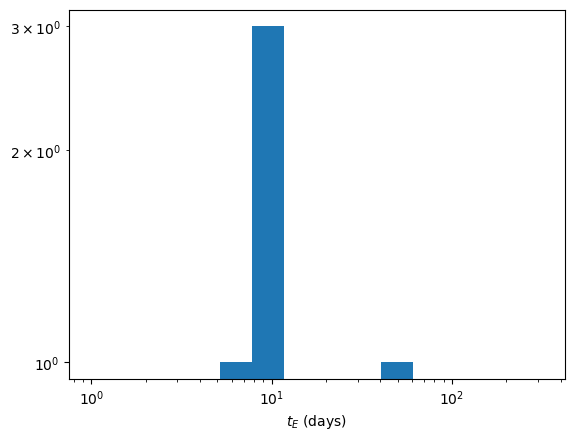

In [22]:
plt.hist(t['t_E'], bins = np.logspace(0, 2.5, 15))
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$t_E$ (days)')

Text(0.5, 0, '$t_E$ (days)')

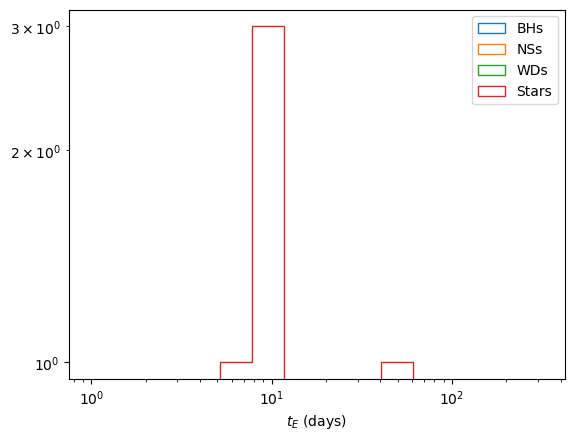

In [23]:
bh_idx = t[t['rem_id_L'] == 103]
ns_idx = t[t['rem_id_L'] == 102]
wd_idx = t[t['rem_id_L'] == 101]
st_idx = t[t['rem_id_L'] == 0]

plt.hist(bh_idx['t_E'], bins = np.logspace(0, 2.5, 15),histtype=u'step', label="BHs")
plt.hist(ns_idx['t_E'], bins = np.logspace(0, 2.5, 15),histtype=u'step', label="NSs")
plt.hist(wd_idx['t_E'], bins = np.logspace(0, 2.5, 15),histtype=u'step', label="WDs")
plt.hist(st_idx['t_E'], bins = np.logspace(0, 2.5, 15),histtype=u'step', label="Stars")
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.xlabel('$t_E$ (days)')

Text(0.5, 0, '$t_E$ (days)')

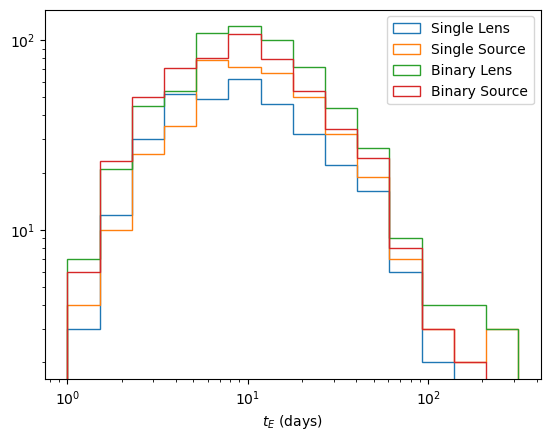

In [34]:
no_companions_lens = t[t['N_companions_L'] == 0]
no_companions_source = t[t['N_companions_S'] == 0]
companions_lens = t[t['N_companions_L'] != 0]
companions_source= t[t['N_companions_S'] != 0]

plt.hist(no_companions_lens['t_E'], bins = np.logspace(0, 2.5, 15),histtype=u'step', label="Single Lens")
plt.hist(no_companions_source['t_E'], bins = np.logspace(0, 2.5, 15),histtype=u'step', label="Single Source")
plt.hist(companions_lens['t_E'], bins = np.logspace(0, 2.5, 15),histtype=u'step', label="Binary Lens")
plt.hist(companions_source['t_E'], bins = np.logspace(0, 2.5, 15),histtype=u'step', label="Binary Source")
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.xlabel('$t_E$ (days)')

Text(0.5, 0, '$t_E$ (days)')

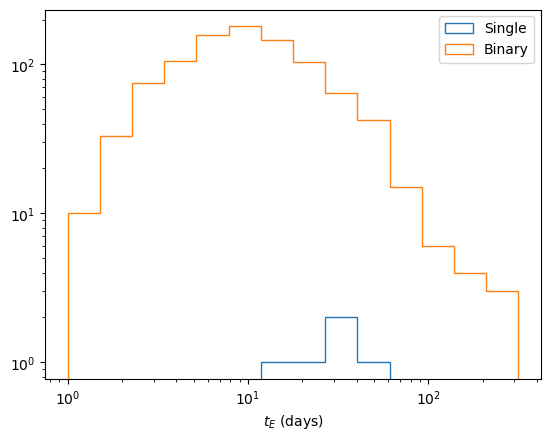

In [42]:
single = no_companions_lens[no_companions_lens['N_companions_S'] == 0]
plbs = no_companions_lens[no_companions_lens['N_companions_S'] != 0]
blps = no_companions_source[no_companions_source['N_companions_L'] != 0]
blbs = companions_source[companions_source['N_companions_L'] != 0]

binary = vstack([plbs, blps, blbs])

plt.hist(single['t_E'], bins = np.logspace(0, 2.5, 15),histtype=u'step', label="Single")
plt.hist(binary['t_E'], bins = np.logspace(0, 2.5, 15),histtype=u'step', label="Binary")
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.xlabel('$t_E$ (days)')

## piE vs tE

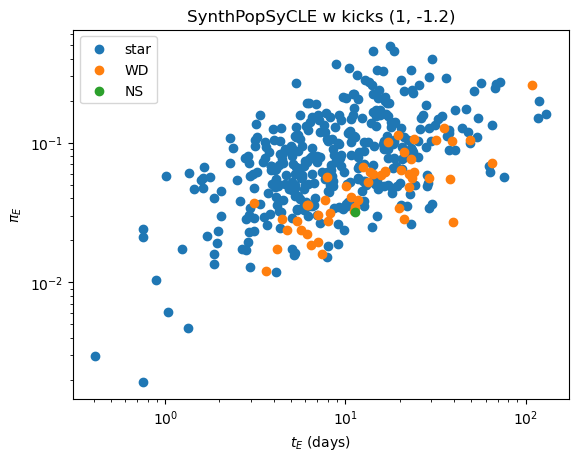

In [9]:
lens_type={0:'star', 101:'WD', 102:'NS', 103:'BH'}
for rem_id in np.unique(t['rem_id_L']):
    idxs = np.where(t['rem_id_L']==rem_id)[0]
    plt.scatter(t['t_E'][idxs], t['pi_E'][idxs], label=lens_type[rem_id])
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$t_E$ (days)')
plt.ylabel('$\pi_E$')
plt.legend(loc=2)
plt.title('SynthPopSyCLE w kicks (1, -1.2)')
plt.savefig('synthpopsycle_lenstype_multiples.png')

## dL vs dS

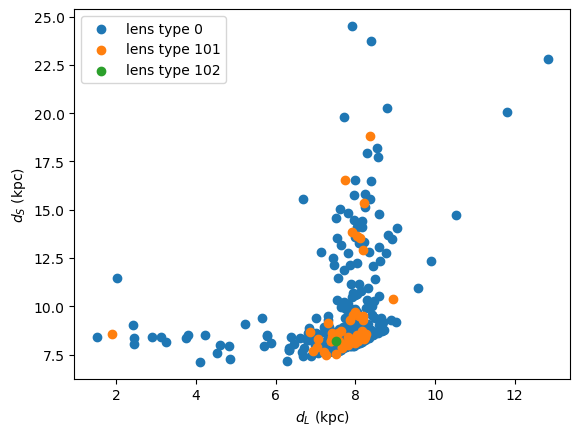

In [11]:
for rem_id in np.unique(t['rem_id_L']):
    idxs = np.where(t['rem_id_L']==rem_id)[0]
    plt.scatter(t['rad_L'][idxs], t['rad_S'][idxs], label='lens type '+str(rem_id))
plt.xlabel('$d_L$ (kpc)')
plt.ylabel('$d_S$ (kpc)')
plt.legend()